# Getting Started: Ground-State Preparation + VarQRTE Quench for H2

This notebook uses **VarQRTE** the way it is most useful in this repo: after a relevant state has already been prepared.

Workflow:

- use `run_vqe()` to prepare an approximate H2 ground state at an initial bond length
- change the Hamiltonian by stretching the bond (a simple quench)
- use `run_qrte(initial_params=...)` to evolve that prepared state in real time under the new Hamiltonian
- track both the post-quench energy and a non-conserved observable, here $\langle Z_0 \rangle$

If you instead evolve an exact eigenstate under the same time-independent Hamiltonian, the dynamics are mostly a global phase and observables stay constant.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from qite import build_hamiltonian, run_qrte
from qite.engine import build_ansatz, make_device, make_state_qnode
from vqe import run_vqe


In [2]:
symbols = ["H", "H"]
coords_prepare = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.74]], dtype=float)
coords_quench = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.30]], dtype=float)

prepare_res = run_vqe(
    molecule="H2",
    symbols=symbols,
    coordinates=coords_prepare,
    ansatz_name="StronglyEntanglingLayers",
    optimizer_name="Adam",
    steps=60,
    stepsize=0.08,
    seed=0,
    plot=False,
    force=True,
)

prepared_params = np.asarray(prepare_res["final_params"], dtype=float)

qrte_res = run_qrte(
    molecule="H2",
    symbols=symbols,
    coordinates=coords_quench,
    ansatz_name="StronglyEntanglingLayers",
    steps=40,
    dt=0.05,
    seed=0,
    plot=False,
    show=False,
    force=True,
    initial_params=prepared_params,
)

times = np.asarray(qrte_res["times"], dtype=float)
energies = np.asarray(qrte_res["energies"], dtype=float)

_, qubits, hf_state, symbols_out, coordinates_out, basis, charge, mapping, unit = build_hamiltonian(
    molecule=None,
    symbols=symbols,
    coordinates=coords_quench,
    charge=0,
    basis="sto-3g",
)
ansatz_fn, _ = build_ansatz(
    "StronglyEntanglingLayers",
    qubits,
    seed=0,
    symbols=symbols_out,
    coordinates=coordinates_out,
    charge=charge,
    basis=basis,
    requires_grad=False,
    hf_state=hf_state,
)
dev = make_device(qubits, noisy=False)
state_qnode = make_state_qnode(dev, ansatz_fn, qubits, noisy=False)
z0_obs = qml.matrix(qml.Z(0), wire_order=list(range(qubits)))
zz01_obs = qml.matrix(qml.Z(0) @ qml.Z(1), wire_order=list(range(qubits)))

z0_vals = []
zz01_vals = []
fidelities = []
param_displacements = []
psi0 = None
for idx, flat_params in enumerate(qrte_res["params_history"]):
    params = np.asarray(flat_params, dtype=float).reshape(qrte_res["final_params_shape"])
    psi = np.asarray(state_qnode(params), dtype=complex)
    if idx == 0:
        psi0 = psi.copy()
    z0_vals.append(float(np.real(np.vdot(psi, z0_obs @ psi))))
    zz01_vals.append(float(np.real(np.vdot(psi, zz01_obs @ psi))))
    fidelities.append(float(abs(np.vdot(psi0, psi)) ** 2))
    param_displacements.append(float(np.linalg.norm(np.ravel(params) - prepared_params)))

z0_vals = np.asarray(z0_vals, dtype=float)
zz01_vals = np.asarray(zz01_vals, dtype=float)
fidelities = np.asarray(fidelities, dtype=float)
param_displacements = np.asarray(param_displacements, dtype=float)

print(f"Preparation geometry: {coords_prepare[1, 2]:.2f} A")
print(f"Quench geometry     : {coords_quench[1, 2]:.2f} A")
print(f"Prepared VQE energy : {float(prepare_res['energy']):+.8f} Ha")
print(f"Post-quench E(t=0)  : {float(energies[0]):+.8f} Ha")
print(f"Post-quench E(t_f)  : {float(qrte_res['energy']):+.8f} Ha")
print(f"span(<Z0>)          : {float(np.ptp(z0_vals)):.6f}")
print(f"span(<Z0 Z1>)       : {float(np.ptp(zz01_vals)):.6f}")
print(f"min fidelity        : {float(np.min(fidelities)):.6f}")
print(f"Max |theta(t)-theta(0)|: {float(np.max(param_displacements)):.6f}")


Step 01/60: E = 0.496363 Ha
Step 02/60: E = 0.445752 Ha
Step 03/60: E = 0.389794 Ha
Step 04/60: E = 0.329590 Ha
Step 05/60: E = 0.266525 Ha
Step 06/60: E = 0.202221 Ha
Step 07/60: E = 0.138458 Ha
Step 08/60: E = 0.077043 Ha
Step 09/60: E = 0.019643 Ha
Step 10/60: E = -0.032490 Ha
Step 11/60: E = -0.078884 Ha
Step 12/60: E = -0.120234 Ha
Step 13/60: E = -0.158354 Ha
Step 14/60: E = -0.195352 Ha
Step 15/60: E = -0.232736 Ha
Step 16/60: E = -0.271178 Ha
Step 17/60: E = -0.310672 Ha
Step 18/60: E = -0.350737 Ha
Step 19/60: E = -0.390585 Ha
Step 20/60: E = -0.429263 Ha
Step 21/60: E = -0.465808 Ha
Step 22/60: E = -0.499377 Ha
Step 23/60: E = -0.529371 Ha
Step 24/60: E = -0.555504 Ha
Step 25/60: E = -0.577824 Ha
Step 26/60: E = -0.596673 Ha
Step 27/60: E = -0.612613 Ha
Step 28/60: E = -0.626329 Ha
Step 29/60: E = -0.638538 Ha
Step 30/60: E = -0.649911 Ha
Step 31/60: E = -0.661030 Ha
Step 32/60: E = -0.672355 Ha
Step 33/60: E = -0.684233 Ha
Step 34/60: E = -0.696920 Ha
Step 35/60: E = -0.7106

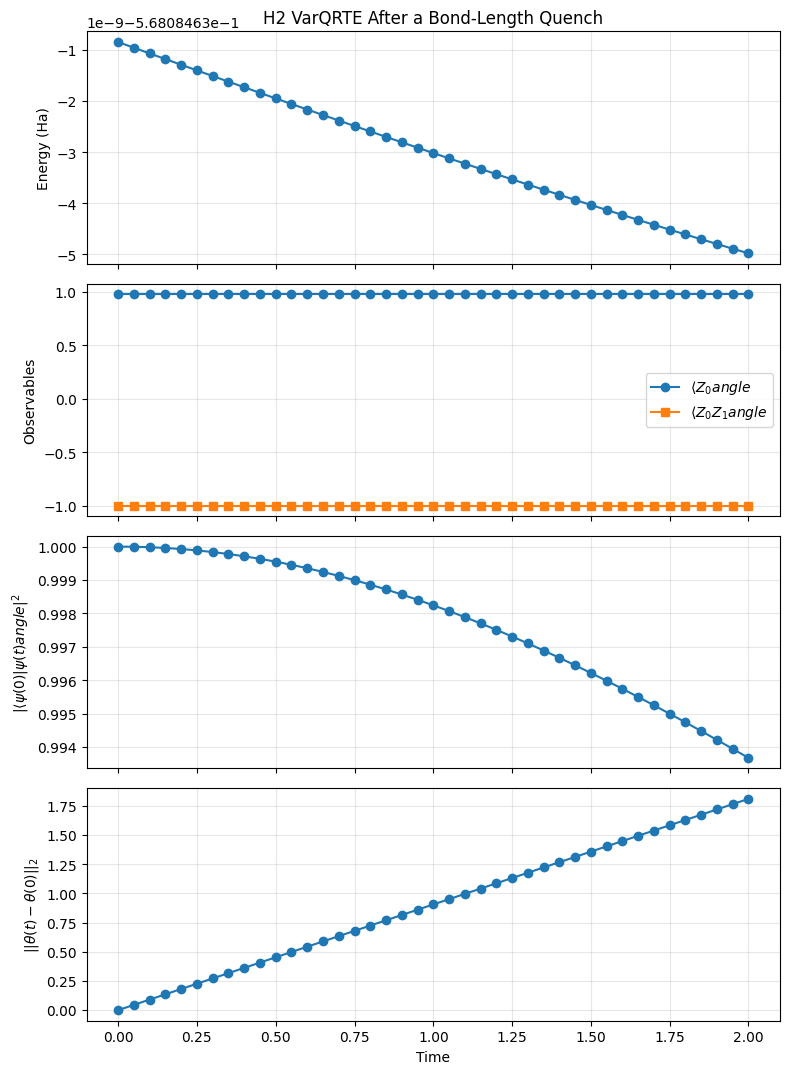

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(8, 11), sharex=True)

axes[0].plot(times, energies, marker="o")
axes[0].set_title("H2 VarQRTE After a Bond-Length Quench")
axes[0].set_ylabel("Energy (Ha)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, z0_vals, marker="o", label=r"$\langle Z_0 \rangle$")
axes[1].plot(times, zz01_vals, marker="s", label=r"$\langle Z_0 Z_1 \rangle$")
axes[1].set_ylabel("Observables")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(times, fidelities, marker="o")
axes[2].set_ylabel(r"$|\langle \psi(0)|\psi(t) \rangle|^2$")
axes[2].grid(True, alpha=0.3)

axes[3].plot(times, param_displacements, marker="o")
axes[3].set_xlabel("Time")
axes[3].set_ylabel(r"$||\theta(t)-\theta(0)||_2$")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
